# TRABAJO PRACTICO INTEGRAL N°1

## Integrantes:

**CRISTIAN DAMIAN FORTUNESKY BARRIOS**

**MATIAS DE VIVO**


## Configuración:

In [21]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)


In [22]:
# --- Configuración de rutas para Actividades 1, 2 y 3 ---

# Definimos la carpeta base del TFI para que todas las rutas sean reproducibles.
carpeta_tfi = Path(".")

# Definimos la carpeta de entrada de imágenes.
carpeta_imagenes_tfi = carpeta_tfi / "img_input_tfi1"

# Creamos la carpeta si no existe para evitar errores de lectura/escritura.
carpeta_imagenes_tfi.mkdir(parents=True, exist_ok=True)

# Definimos carpeta de salidas para resultados procesados.
carpeta_salidas_tfi = carpeta_tfi / "img_output_tfi1"
carpeta_salidas_tfi.mkdir(parents=True, exist_ok=True)

print(f"Carpeta de imágenes: {carpeta_imagenes_tfi.resolve()}")
print(f"Carpeta de salidas: {carpeta_salidas_tfi.resolve()}")

Carpeta de imágenes: C:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\img_input_tfi1
Carpeta de salidas: C:\Programacion\repositorio-ingenieria-datos\ifts24\ifts24-lab-pdi-2026\005 - TFI_1\img_output_tfi1


## Imagen obtenida mediante cámara oscura

**Origen de la imagen:** `img_input_tfi1/img-camara-oscura.jpg`  
**Salida final solicitada:** `img_output_tfi1/img-camara-oscura-final.jpg`

Se utiliza la imagen extraida en camara oscura donde se busca generar un diagnostico inicial que nos permita indentificar areas problematicas de mejora y restauración.

## Diagnóstico antes de filtrar

La restauración de la imagen de cámara oscura se plantea como un **pipeline justificado por diagnóstico**.

**Imagen de entrada esperada:** `005 - TFI_1/img_input_tfi1/img-camara-oscura.jpg`  
**Imagen final generada:** `005 - TFI_1/img_output_tfi1/img-camara-oscura-final.jpg`

### Preguntas de diagnóstico inicial

| Pregunta | Respuesta técnica para esta imagen |
|---|---|
| ¿La imagen está oscura o clara? | La imagen está muy oscura. Cuesta ver detalles porque casi toda la imagen está en tonos negros o grises oscuros. |
| ¿Tiene bajo contraste? | Sí. El objeto del centro no se diferencia mucho del fondo, entonces todo se ve “lavado” o poco definido. |
| ¿Hay ruido? | Sí. Se ve granulado en la imagen, especialmente en las partes oscuras. Eso suele pasar cuando hay poca luz. |
| ¿La iluminación es desigual? | Sí. La luz está concentrada en el centro y el resto de la imagen queda muy oscuro. |
| ¿Existe deformación geométrica? | No se ve una deformación fuerte de perspectiva. El principal problema no es la forma, sino que la imagen está borrosa y oscura. |
| ¿Hay manchas o daños localizados? | No hay manchas importantes ni partes rotas. El problema afecta a toda la imagen en general. |
| ¿Qué parte importa? | La parte importante es el centro, donde aparece la proyección de la cámara oscura. El resto del fondo no aporta mucha información. |

### Diagnóstico visual propio

El principal problema de la imagen es que salió borrosa, muy oscura y con poco contraste.
La cámara no logró capturar bien los detalles finos, por eso la imagen se ve poco definida y “apagada”.

Debido a eso, no es posible recuperar completamente la nitidez original. El objetivo realista del procesamiento es mejorar la visibilidad de la imagen y hacer más clara la proyección central, sin generar detalles falsos.

**Decisiones descartadas desde el diagnóstico:**

- No aplicar filtros de nitidez agresivos (sharpening), porque podrían empeorar el ruido y crear bordes artificiales.
- No usar una ecualización global muy fuerte como resultado final, porque puede hacer que el fondo oscuro y el ruido se vuelvan demasiado visibles.

## Carga de imagen y funciones auxiliares

La celda siguiente deja preparado el flujo reproducible. Si la imagen todavía no está cargada en la carpeta de entrada, el cuaderno no falla: muestra una advertencia y mantiene documentado el pipeline para ejecutarlo cuando se incorpore la fotografía propia solicitada por la consigna.

Imagen cargada: img_input_tfi1\img-camara-oscura.jpg
Dimensiones: 3024 x 1601 px


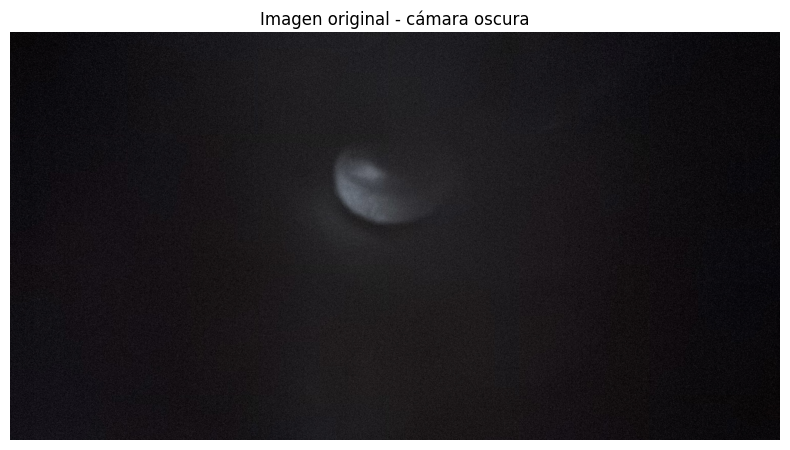

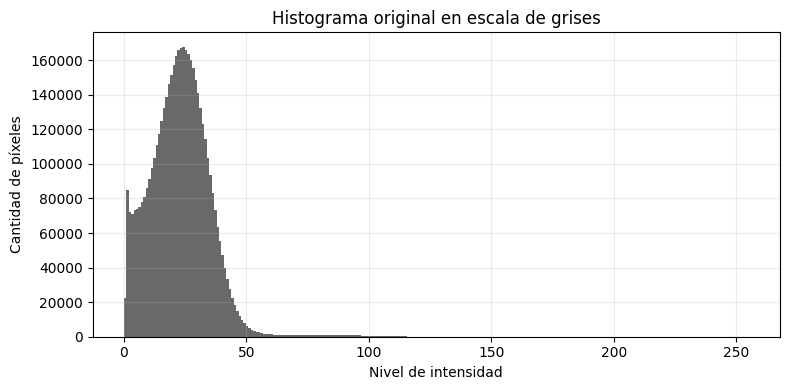

In [23]:
# --- Actividad 1: rutas y utilidades ---

nombre_imagen_camara = "img-camara-oscura.jpg"
ruta_camara = carpeta_imagenes_tfi / nombre_imagen_camara
ruta_final_camara = carpeta_salidas_tfi / "img-camara-oscura-final.jpg"
ruta_comparacion_camara = carpeta_salidas_tfi / "img-camara-oscura-comparacion.jpg"
ruta_histogramas_camara = carpeta_salidas_tfi / "img-camara-oscura-histogramas.jpg"


def cargar_rgb(ruta):
    """Carga una imagen con OpenCV y la devuelve en RGB para visualizar con Matplotlib."""
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def guardar_rgb(ruta, imagen_rgb, calidad=95):
    """Guarda una imagen RGB en disco usando codificación BGR de OpenCV."""
    ruta.parent.mkdir(parents=True, exist_ok=True)
    imagen_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(ruta), imagen_bgr, [cv2.IMWRITE_JPEG_QUALITY, calidad])


def mostrar_imagen(imagen, titulo="Imagen", cmap=None):
    plt.figure(figsize=(8, 5))
    plt.imshow(imagen, cmap=cmap)
    plt.title(titulo)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo="Histograma"):
    plt.figure(figsize=(8, 4))
    plt.hist(imagen_gris.ravel(), bins=256, range=(0, 255), color="dimgray")
    plt.title(titulo)
    plt.xlabel("Nivel de intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def calcular_metricas_gris(imagen_gris):
    """Calcula métricas simples para sostener el diagnóstico y la comparación."""
    hist = cv2.calcHist([imagen_gris], [0], None, [256], [0, 256]).ravel()
    prob = hist / max(hist.sum(), 1)
    prob = prob[prob > 0]

    p1, p5, p95, p99 = np.percentile(imagen_gris, [1, 5, 95, 99])
    mediana_filtrada = cv2.medianBlur(imagen_gris, 3)
    ruido_estimado = float(np.std(imagen_gris.astype(np.float32) - mediana_filtrada.astype(np.float32)))

    return {
        "brillo_medio": float(np.mean(imagen_gris)),
        "contraste_std": float(np.std(imagen_gris)),
        "p1": float(p1),
        "p5": float(p5),
        "p95": float(p95),
        "p99": float(p99),
        "rango_dinamico_p1_p99": float(p99 - p1),
        "nitidez_laplaciano": float(cv2.Laplacian(imagen_gris, cv2.CV_64F).var()),
        "entropia": float(-np.sum(prob * np.log2(prob))),
        "ruido_estimado": ruido_estimado,
        "banding_vertical_estimado": float(np.std(np.mean(imagen_gris, axis=0))),
    }


def imprimir_metricas(nombre, metricas):
    print(f"\n{nombre}")
    print("-" * len(nombre))
    for clave, valor in metricas.items():
        print(f"{clave:28s}: {valor:8.3f}")


if ruta_camara.exists():
    imagen_camara_rgb = cargar_rgb(ruta_camara)
    imagen_camara_gris = cv2.cvtColor(imagen_camara_rgb, cv2.COLOR_RGB2GRAY)
    print(f"Imagen cargada: {ruta_camara}")
    print(f"Dimensiones: {imagen_camara_rgb.shape[1]} x {imagen_camara_rgb.shape[0]} px")
    mostrar_imagen(imagen_camara_rgb, "Imagen original - cámara oscura")
    mostrar_histograma_gris(imagen_camara_gris, "Histograma original en escala de grises")
else:
    imagen_camara_rgb = None
    imagen_camara_gris = None
    print(f"ADVERTENCIA: no se encontró {ruta_camara}")
    print("Colocar allí la fotografía propia de cámara oscura para ejecutar el procesamiento completo.")

El histograma confirma que la imagen está subexpuesta (muy oscura) y posee bajo contraste. La mayoría de los píxeles se concentra en tonos oscuros y prácticamente no aparecen valores altos de intensidad. Esto indica que la imagen utiliza solo una pequeña parte del rango tonal disponible, provocando una apariencia apagada y poca separación entre el objeto central y el fondo. Además, el fondo oscuro domina gran parte de la distribución tonal.

## Diagnóstico cuantitativo

El histograma permite traducir observaciones visuales a términos medibles:

- Si la media y los percentiles altos quedan bajos, hay **subexposición**.
- Si la desviación estándar y el rango entre percentiles son reducidos, hay **bajo contraste**.
- Si el residuo respecto de una mediana local es alto, hay **ruido fino**.
- Si el promedio por columnas varía de forma sistemática, puede existir **banding vertical** o iluminación estructurada.

Estas métricas no reemplazan el criterio visual, pero ayudan a justificar por qué se elige una mejora local y suave.

In [24]:
if imagen_camara_gris is not None:
    metricas_original = calcular_metricas_gris(imagen_camara_gris)
    imprimir_metricas("Métricas de diagnóstico - original", metricas_original)

    diagnostico_textual = []
    if metricas_original["brillo_medio"] < 90:
        diagnostico_textual.append("subexposición / imagen oscura")
    if metricas_original["contraste_std"] < 45:
        diagnostico_textual.append("bajo contraste global")
    if metricas_original["ruido_estimado"] > 4:
        diagnostico_textual.append("ruido fino visible o probable")
    if metricas_original["nitidez_laplaciano"] < 80:
        diagnostico_textual.append("baja nitidez aparente / desenfoque")

    print("\nDiagnóstico automático orientativo:")
    print(", ".join(diagnostico_textual) if diagnostico_textual else "Sin degradación fuerte según umbrales simples.")
else:
    print("Diagnóstico cuantitativo pendiente: falta la imagen de entrada.")


Métricas de diagnóstico - original
----------------------------------
brillo_medio                :   22.681
contraste_std               :   12.531
p1                          :    1.000
p5                          :    3.000
p95                         :   41.000
p99                         :   58.000
rango_dinamico_p1_p99       :   57.000
nitidez_laplaciano          :  649.068
entropia                    :    5.535
ruido_estimado              :    6.199
banding_vertical_estimado   :    8.108

Diagnóstico automático orientativo:
subexposición / imagen oscura, bajo contraste global, ruido fino visible o probable


### Explicación breve de las métricas obtenidas:

Brillo medio (22.68):
- Indica que la imagen es muy oscura, ya que el promedio de intensidad está cerca del negro.

Contraste (12.53):
- El contraste es bajo, por eso los tonos de la imagen son muy parecidos y el objeto central se diferencia poco del fondo.

Percentiles (p1, p5, p95, p99):
- Muestran que casi toda la imagen se concentra en tonos oscuros y que incluso las zonas más iluminadas siguen siendo relativamente oscuras.

Rango dinámico (57):
- Confirma que la imagen utiliza una parte pequeña del rango tonal disponible, generando una apariencia apagada.

Nitidez Laplaciana (649):
- Intenta medir presencia de bordes y detalles, aunque puede verse afectada por el ruido. Visualmente la imagen sigue presentando desenfoque.

Entropía (5.53):
- Representa la cantidad de información visual. La imagen tiene información limitada debido a la oscuridad y la falta de detalle.

Ruido estimado (6.19):
- Confirma la presencia de granulado visible, especialmente en zonas oscuras.

Banding vertical (8.10):
- Sugiere la existencia de leves líneas o variaciones verticales en el fondo de la imagen.

## Recorte de región de interés

Primero se recorta la zona central de la imagen porque ahí aparece la proyección de la cámara oscura, que es la parte importante para analizar.

El fondo oscuro ocupa gran parte de la imagen y afecta el histograma y las métricas, ya que agrega muchos píxeles negros que no aportan información útil.

El recorte permite:

1. enfocar el análisis en la zona importante
2. reducir la influencia del fondo oscuro
3. mejorar el procesamiento posterior de contraste y reducción de ruido.

El recorte se realiza automáticamente detectando las zonas más iluminadas de la imagen. Si esa detección falla, el sistema utiliza un recorte central más conservador.

ROI seleccionada (x0, y0, x1, y1): (0, 0, np.int32(2599), 1601)


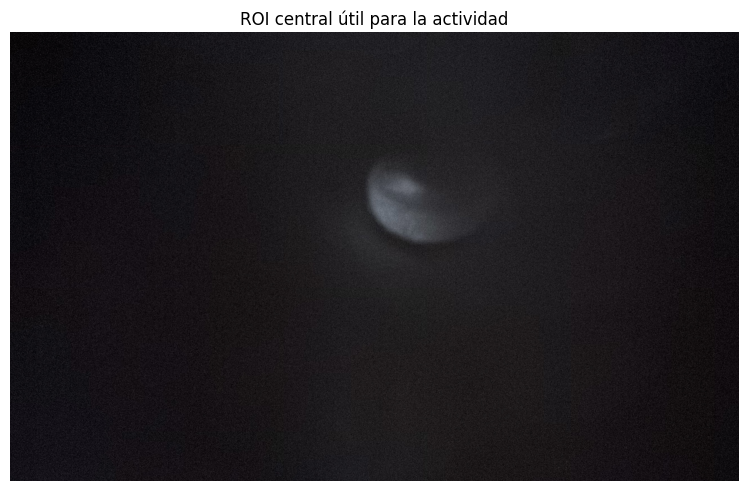

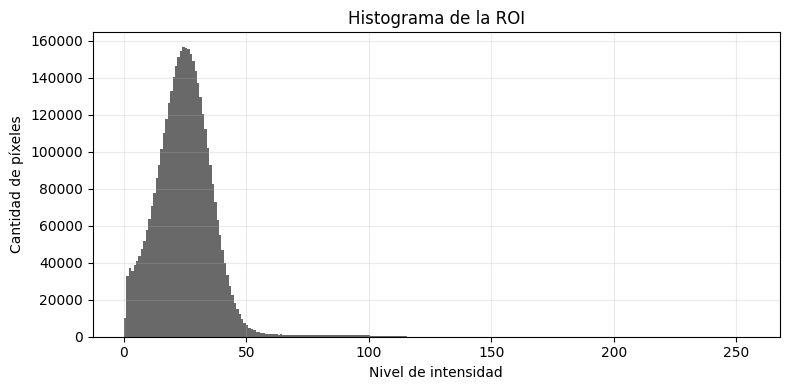

In [25]:
def recortar_roi_camara(imagen_rgb, margen=35, percentil=88):
    """Recorta automáticamente la zona informativa; si no hay señal clara, usa recorte central."""
    gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)
    alto, ancho = gris.shape

    umbral = np.percentile(gris, percentil)
    mascara = (gris >= umbral).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, kernel, iterations=2)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel, iterations=1)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mascara, connectivity=8)
    if num_labels <= 1:
        usar_recorte_central = True
    else:
        areas = stats[1:, cv2.CC_STAT_AREA]
        idx = int(np.argmax(areas)) + 1
        area_relativa = stats[idx, cv2.CC_STAT_AREA] / float(alto * ancho)
        usar_recorte_central = area_relativa < 0.005

    if usar_recorte_central:
        x0, x1 = int(ancho * 0.15), int(ancho * 0.85)
        y0, y1 = int(alto * 0.15), int(alto * 0.85)
    else:
        x, y, w, h, _ = stats[idx]
        x0 = max(0, x - margen)
        y0 = max(0, y - margen)
        x1 = min(ancho, x + w + margen)
        y1 = min(alto, y + h + margen)

        # Evita recortes demasiado cerrados que podrían perder contexto de la proyección.
        min_w, min_h = int(ancho * 0.35), int(alto * 0.35)
        if (x1 - x0) < min_w:
            cx = (x0 + x1) // 2
            x0 = max(0, cx - min_w // 2)
            x1 = min(ancho, x0 + min_w)
        if (y1 - y0) < min_h:
            cy = (y0 + y1) // 2
            y0 = max(0, cy - min_h // 2)
            y1 = min(alto, y0 + min_h)

    roi = imagen_rgb[y0:y1, x0:x1]
    return roi, (x0, y0, x1, y1)


if imagen_camara_rgb is not None:
    imagen_roi_rgb, caja_roi = recortar_roi_camara(imagen_camara_rgb)
    imagen_roi_gris = cv2.cvtColor(imagen_roi_rgb, cv2.COLOR_RGB2GRAY)
    print(f"ROI seleccionada (x0, y0, x1, y1): {caja_roi}")
    mostrar_imagen(imagen_roi_rgb, "ROI central útil para la actividad")
    mostrar_histograma_gris(imagen_roi_gris, "Histograma de la ROI")
else:
    imagen_roi_rgb = None
    imagen_roi_gris = None
    caja_roi = None
    print("Recorte ROI pendiente: falta la imagen de entrada.")

## Estrategias comparadas

### Estrategia A 

**ROI → escala de grises → CLAHE suave → mediana 3×3 → ajuste leve de brillo/contraste**

Parámetros principales:

- `clipLimit = 1.5` Se usa un valor bajo para mejorar el contraste de forma suave y evitar exagerar el ruido.
- `tileGridSize = (8, 8)` Divide la imagen en regiones medianas para mejorar contraste local sin generar cambios artificiales.
- `medianBlur = 3` Se aplica una mediana pequeña para reducir granulado sin perder demasiado detalle.
- `alpha = 1.2`, `beta = 10` Se utilizan ajustes leves de contraste y brillo para aclarar la imagen sin “quemar” las zonas iluminadas.

Se elige como candidata principal porque mejora la visibilidad y el contraste de la proyección central sin modificar agresivamente la imagen original. La mediana posterior ayuda a reducir el ruido resaltado por CLAHE.

El objetivo general es recuperar legibilidad y contraste manteniendo una apariencia natural y evitando amplificar el ruido o crear detalles falsos.

### Estrategia B 

**ROI → escala de grises → equalizeHist global → Gaussian blur → sharpening suave**

Parámetros principales:

**equalizeHist global**
Se usa para aumentar el contraste de toda la imagen de manera rápida y fuerte.

**Gaussian blur (3x3)**
Se aplica un suavizado leve para reducir parte del ruido generado por la ecualización.

**sharpening suave**
Se intenta recuperar algo de definición y resaltar bordes después del suavizado.

Esta estrategia se utiliza como comparación porque permite observar los problemas de una mejora demasiado agresiva. Aunque aumenta mucho el contraste y hace más visible la proyección central, también exagera el ruido, el granulado y las bandas verticales del fondo.

Además, algunas zonas iluminadas quedan sobreexpuestas y aparecen bordes artificiales, haciendo que la imagen pierda naturalidad.

## Funciones para implementar estrategias

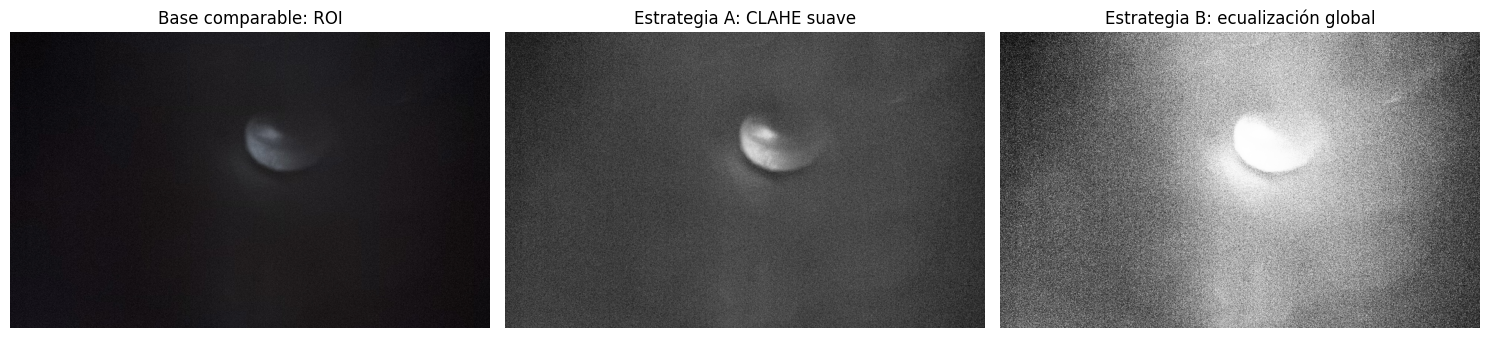

In [26]:
def estrategia_a_clahe_suave(imagen_roi_rgb, clip_limit=1.5, tile_grid=(8, 8), alpha=1.2, beta=10):
    gris = cv2.cvtColor(imagen_roi_rgb, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    mejorada = clahe.apply(gris)
    mejorada = cv2.medianBlur(mejorada, 3)
    mejorada = cv2.convertScaleAbs(mejorada, alpha=alpha, beta=beta)
    return cv2.cvtColor(mejorada, cv2.COLOR_GRAY2RGB)


def estrategia_b_ecualizacion_global(imagen_roi_rgb):
    gris = cv2.cvtColor(imagen_roi_rgb, cv2.COLOR_RGB2GRAY)
    ecualizada = cv2.equalizeHist(gris)
    suavizada = cv2.GaussianBlur(ecualizada, (3, 3), 0)
    desenfocada = cv2.GaussianBlur(suavizada, (0, 0), 1.0)
    sharpen_suave = cv2.addWeighted(suavizada, 1.25, desenfocada, -0.25, 0)
    return cv2.cvtColor(sharpen_suave, cv2.COLOR_GRAY2RGB)


if imagen_roi_rgb is not None:
    imagen_estrategia_a = estrategia_a_clahe_suave(imagen_roi_rgb)
    imagen_estrategia_b = estrategia_b_ecualizacion_global(imagen_roi_rgb)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(imagen_roi_rgb)
    ax[0].set_title("Base comparable: ROI")
    ax[1].imshow(imagen_estrategia_a)
    ax[1].set_title("Estrategia A: CLAHE suave")
    ax[2].imshow(imagen_estrategia_b)
    ax[2].set_title("Estrategia B: ecualización global")
    for eje in ax:
        eje.axis("off")
    plt.tight_layout()
    plt.show()
else:
    imagen_estrategia_a = None
    imagen_estrategia_b = None
    print("Comparación de estrategias pendiente: falta la imagen de entrada.")

## Comparación objetiva y elección final

La comparación no se basa únicamente en cuál “se ve mejor”, sino también en cómo cambian las métricas sobre la misma región de interés (ROI).

**Qué muestran las métricas:**
- La imagen original tiene brillo y contraste bajos, lo que confirma que la proyección está oscura y poco definida.
- La Estrategia A aumenta el brillo y el contraste de manera moderada, haciendo más visible la proyección central sin exagerar demasiado el ruido.
- La Estrategia B aumenta todavía más el contraste, pero también hace mucho más visibles el granulado, las bandas verticales y las zonas sobreexpuestas.

**La Estrategia A logra una mejora más equilibrada:**

- La proyección central se distingue mejor
- Aumenta la legibilidad
- Mantiene una apariencia relativamente natural
- Controla mejor el ruido.

**En cambio, la Estrategia B genera una mejora demasiado agresiva:**

- El fondo se vuelve muy ruidoso,
- Aparecen halos y zonas “quemadas”,
- La imagen pierde naturalidad.


**Elección final:**

- Se selecciona la Estrategia A (CLAHE suave) como resultado final porque mejora la visibilidad y el contraste sin convertir el ruido y los artefactos en el elemento dominante de la imagen.

In [27]:
if imagen_roi_gris is not None:
    gris_a = cv2.cvtColor(imagen_estrategia_a, cv2.COLOR_RGB2GRAY)
    gris_b = cv2.cvtColor(imagen_estrategia_b, cv2.COLOR_RGB2GRAY)

    metricas_roi = calcular_metricas_gris(imagen_roi_gris)
    metricas_a = calcular_metricas_gris(gris_a)
    metricas_b = calcular_metricas_gris(gris_b)

    imprimir_metricas("Base comparable - ROI", metricas_roi)
    imprimir_metricas("Estrategia A - CLAHE suave", metricas_a)
    imprimir_metricas("Estrategia B - ecualización global", metricas_b)

    print("\nLectura técnica:")
    print("- La estrategia A busca mejora moderada de contraste local y control de ruido.")
    print("- La estrategia B puede aumentar más el contraste numérico, pero tiende a exagerar ruido y halos.")
    print("- Por coherencia con el diagnóstico, se selecciona la Estrategia A como resultado final.")
else:
    metricas_roi = None
    metricas_a = None
    metricas_b = None
    print("Comparación objetiva pendiente: falta la imagen de entrada.")


Base comparable - ROI
---------------------
brillo_medio                :   24.521
contraste_std               :   12.155
p1                          :    1.000
p5                          :    6.000
p95                         :   42.000
p99                         :   63.000
rango_dinamico_p1_p99       :   62.000
nitidez_laplaciano          :  647.840
entropia                    :    5.498
ruido_estimado              :    6.185
banding_vertical_estimado   :    7.216

Estrategia A - CLAHE suave
--------------------------
brillo_medio                :   67.962
contraste_std               :   18.969
p1                          :   27.000
p5                          :   39.000
p95                         :   93.000
p99                         :  129.000
rango_dinamico_p1_p99       :  102.000
nitidez_laplaciano          :  494.058
entropia                    :    5.827
ruido_estimado              :    5.470
banding_vertical_estimado   :    9.945

Estrategia B - ecualización global
------

## Conclusión final y guardado

Se guarda como resultado final la Estrategia A porque logra una mejora más equilibrada de la imagen. La proyección central se vuelve más visible y con mejor contraste, pero sin exagerar el ruido ni generar demasiados artefactos artificiales.

**Problemas que mejora:**
- La imagen se ve menos oscura
- Mejora el contraste de la proyección central
- Aumenta la legibilidad de la zona importante
- Mantiene el ruido en niveles aceptables mientras mejora la visibilidad de la proyección central

**Problemas que no resuelve completamente:**
- La imagen sigue teniendo desenfoque;
- No se pueden recuperar detalles que nunca fueron capturados;
- Todavía se observan leves bandas verticales en el fondo;
- La poca iluminación original limita la calidad final.


La imagen obtenida mediante cámara oscura presenta principalmente problemas de oscuridad, poco contraste y desenfoque. Además, existe ruido visible debido a las condiciones de baja iluminación.

Por este motivo, el procesamiento final busca mejorar la visibilidad y el contraste de forma moderada, sin intentar “inventar” detalles que no existen realmente en la captura original.

**Elección final:**

Se selecciona la Estrategia A:

ROI → escala de grises → CLAHE suave → mediana 3×3 → ajuste leve de brillo/contraste

**Justificación:**
- El recorte ROI permite trabajar solo sobre la zona importante.
- CLAHE mejora el contraste local sin modificar agresivamente toda la imagen.
- La mediana ayuda a reducir ruido fino.
- El ajuste de brillo y contraste es suave para mantener una apariencia natural.
- La estrategia con ecualización global fue útil como comparación, pero aumentó demasiado el ruido y las bandas del fondo.
- Límites reconocidos

El desenfoque óptico no puede corregirse completamente mediante posprocesamiento. Si la captura original no tiene suficiente detalle, ningún filtro puede reconstruirlo de manera realista.

**La mejora más importante debería realizarse directamente en la captura:**

- Mejor iluminación,
- Mayor estabilidad,
- ISO más bajo,
- Exposición más controlada,
- Un orificio mejor ajustado para la cámara oscura.

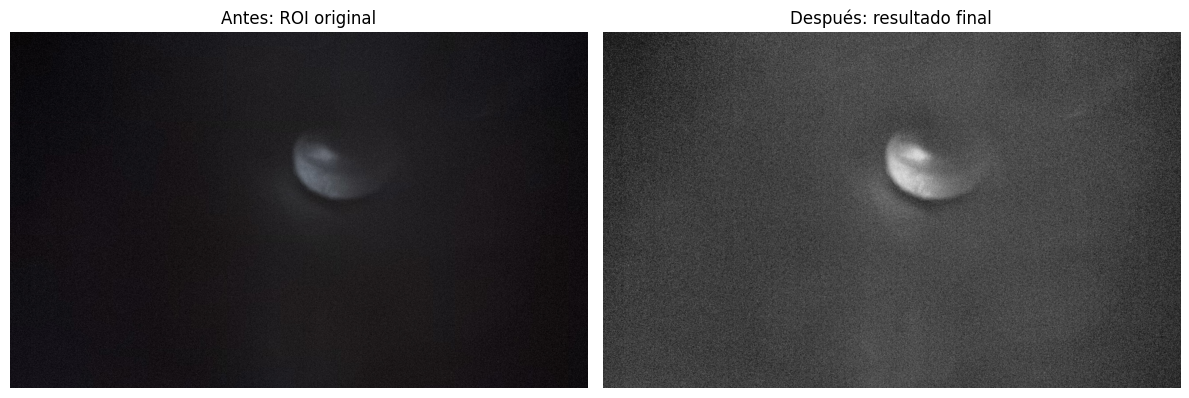

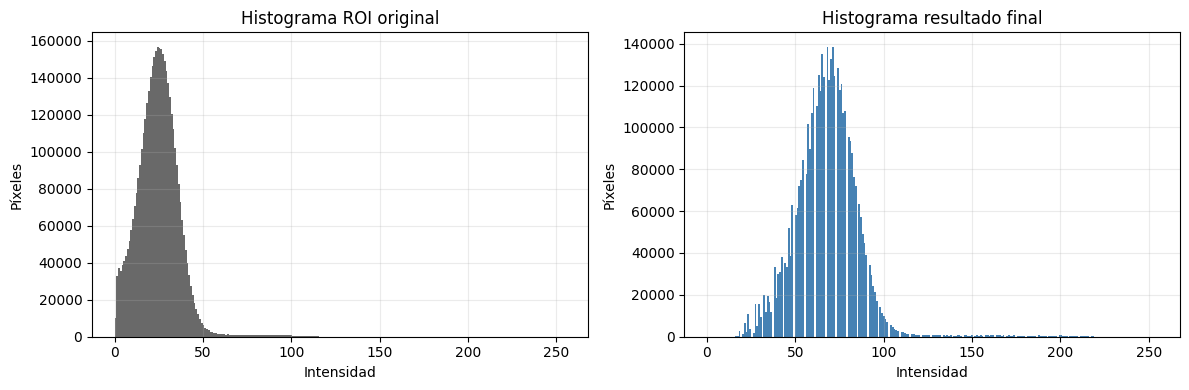

Imagen final guardada en: img_output_tfi1\img-camara-oscura-final.jpg
Comparación antes/después guardada en: img_output_tfi1\img-camara-oscura-comparacion.jpg
Histogramas guardados en: img_output_tfi1\img-camara-oscura-histogramas.jpg


In [28]:
if imagen_estrategia_a is not None:
    imagen_camara_final = imagen_estrategia_a
    guardar_rgb(ruta_final_camara, imagen_camara_final)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(imagen_roi_rgb)
    ax[0].set_title("Antes: ROI original")
    ax[1].imshow(imagen_camara_final)
    ax[1].set_title("Después: resultado final")
    for eje in ax:
        eje.axis("off")
    plt.tight_layout()
    plt.savefig(ruta_comparacion_camara, dpi=150, bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].hist(imagen_roi_gris.ravel(), bins=256, range=(0, 255), color="dimgray")
    ax[0].set_title("Histograma ROI original")
    ax[0].set_xlabel("Intensidad")
    ax[0].set_ylabel("Píxeles")
    ax[1].hist(cv2.cvtColor(imagen_camara_final, cv2.COLOR_RGB2GRAY).ravel(), bins=256, range=(0, 255), color="steelblue")
    ax[1].set_title("Histograma resultado final")
    ax[1].set_xlabel("Intensidad")
    ax[1].set_ylabel("Píxeles")
    for eje in ax:
        eje.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(ruta_histogramas_camara, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Imagen final guardada en: {ruta_final_camara}")
    print(f"Comparación antes/después guardada en: {ruta_comparacion_camara}")
    print(f"Histogramas guardados en: {ruta_histogramas_camara}")
else:
    imagen_camara_final = None
    print("Guardado pendiente: falta la imagen de entrada.")